# VoxIntel — 14: High-Impact Error Analysis

## Goal

This notebook shifts the project from taxonomy construction to **semantic impact analysis**.

The key research question is no longer whether ASR got better. That has already been shown.
The important question now is:

> Which error categories actually change downstream intent understanding, which are benign, and which are improved by ASR fine-tuning?

This notebook uses the canonical post-consolidation taxonomy and turns it into research claims that are more meaningful than raw WER alone.

## Main questions answered here

1. Which categories are most harmful downstream?
2. Which categories are mostly benign?
3. Which categories recover most after fine-tuning?
4. Which intents remain fragile under specific categories?
5. Which categories persist even after fine-tuning?
6. How much explanatory signal do coarse numeric proxies like edit count provide by themselves?


## Cell 0 — Make sure `src` is importable


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports


In [2]:
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")


## Cell 2 — Load canonical post-consolidation outputs


In [3]:
REPORTS_DIR = PROJECT_ROOT / "reports"

paths = {
    "taxonomy": REPORTS_DIR / "error_taxonomy_dataset.csv",
    "error_impact_matrix": REPORTS_DIR / "error_impact_matrix.csv",
    "intent_fragility": REPORTS_DIR / "intent_fragility.csv",
    "metric_comparison": REPORTS_DIR / "metric_comparison.csv",
}

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing canonical report file: {path}")

taxonomy_df = pd.read_csv(paths["taxonomy"])
error_impact_matrix_df = pd.read_csv(paths["error_impact_matrix"])
intent_fragility_df = pd.read_csv(paths["intent_fragility"])
metric_comparison_df = pd.read_csv(paths["metric_comparison"])

print(taxonomy_df.shape)
display(metric_comparison_df)


(8688, 41)


,transcript_source,n_samples,accuracy,precision_macro,recall_macro,macro_f1,top3_accuracy,mean_confidence,median_confidence
0,ground_truth,8688,0.857735,0.696729,0.715841,0.703180,0.944406,0.922548,0.980201
1,baseline,8688,0.384899,0.404243,0.283904,0.308180,0.515654,0.734901,0.837562
2,finetuned,8688,0.734346,0.572839,0.570868,0.555436,0.845419,0.861017,0.968617


## Cell 3 — Semantic impact framing


In [ ]:
impact_overview_df = pd.DataFrame([
    {
        "system": "baseline",
        "high_impact_rate": (taxonomy_df["baseline_impact"] == "high_impact").mean(),
        "low_impact_rate": (taxonomy_df["baseline_impact"] == "low_impact").mean(),
        "no_error_rate": (taxonomy_df["baseline_impact"] == "no_error").mean(),
    },
    {
        "system": "finetuned",
        "high_impact_rate": (taxonomy_df["finetuned_impact"] == "high_impact").mean(),
        "low_impact_rate": (taxonomy_df["finetuned_impact"] == "low_impact").mean(),
        "no_error_rate": (taxonomy_df["finetuned_impact"] == "no_error").mean(),
    },
])

display(impact_overview_df)

,system,high_impact_rate,low_impact_rate,no_error_rate
0,baseline,0.615101,0.333103,0.051796
1,finetuned,0.265654,0.555939,0.178407


## Cell 4 — The canonical semantic impact matrix


In [5]:
semantic_impact_df = error_impact_matrix_df.copy().sort_values(
    ["system", "intent_failure_rate"], ascending=[True, False]
).reset_index(drop=True)

display(semantic_impact_df)


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,baseline,number_error,488,0.682377,0.317623,6.598361,0.229696
1,baseline,proper_noun_error,7573,0.645451,0.354549,4.054008,0.302066
2,baseline,deletion,19,0.210526,0.789474,1.105263,0.787425
3,baseline,no_error,565,0.203540,0.000000,0.000000,1.000000
4,baseline,entity_error,43,0.093023,0.906977,1.325581,0.722733
5,finetuned,proper_noun_error,6487,0.298289,0.701711,2.310775,0.529471
6,finetuned,number_error,253,0.288538,0.711462,3.861660,0.488153
7,finetuned,no_error,1843,0.158980,0.000000,0.000000,1.000000
8,finetuned,deletion,59,0.084746,0.915254,1.084746,0.796427
9,finetuned,entity_error,46,0.043478,0.956522,1.152174,0.769953


## Cell 5 — Most harmful categories


In [6]:
most_harmful_baseline_df = semantic_impact_df[semantic_impact_df["system"] == "baseline"].sort_values(
    ["intent_failure_rate", "samples"], ascending=[False, False]
).reset_index(drop=True)

most_harmful_finetuned_df = semantic_impact_df[semantic_impact_df["system"] == "finetuned"].sort_values(
    ["intent_failure_rate", "samples"], ascending=[False, False]
).reset_index(drop=True)

print("Most harmful baseline categories:")
display(most_harmful_baseline_df)

print("Most harmful fine-tuned categories:")
display(most_harmful_finetuned_df)


Most harmful baseline categories:


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,baseline,number_error,488,0.682377,0.317623,6.598361,0.229696
1,baseline,proper_noun_error,7573,0.645451,0.354549,4.054008,0.302066
2,baseline,deletion,19,0.210526,0.789474,1.105263,0.787425
3,baseline,no_error,565,0.203540,0.000000,0.000000,1.000000
4,baseline,entity_error,43,0.093023,0.906977,1.325581,0.722733


Most harmful fine-tuned categories:


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,finetuned,proper_noun_error,6487,0.298289,0.701711,2.310775,0.529471
1,finetuned,number_error,253,0.288538,0.711462,3.861660,0.488153
2,finetuned,no_error,1843,0.158980,0.000000,0.000000,1.000000
3,finetuned,deletion,59,0.084746,0.915254,1.084746,0.796427
4,finetuned,entity_error,46,0.043478,0.956522,1.152174,0.769953


## Cell 6 — Most benign categories


In [7]:
most_benign_baseline_df = semantic_impact_df[semantic_impact_df["system"] == "baseline"].sort_values(
    ["low_impact_rate", "samples"], ascending=[False, False]
).reset_index(drop=True)

most_benign_finetuned_df = semantic_impact_df[semantic_impact_df["system"] == "finetuned"].sort_values(
    ["low_impact_rate", "samples"], ascending=[False, False]
).reset_index(drop=True)

print("Most benign baseline categories:")
display(most_benign_baseline_df)

print("Most benign fine-tuned categories:")
display(most_benign_finetuned_df)


Most benign baseline categories:


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,baseline,entity_error,43,0.093023,0.906977,1.325581,0.722733
1,baseline,deletion,19,0.210526,0.789474,1.105263,0.787425
2,baseline,proper_noun_error,7573,0.645451,0.354549,4.054008,0.302066
3,baseline,number_error,488,0.682377,0.317623,6.598361,0.229696
4,baseline,no_error,565,0.203540,0.000000,0.000000,1.000000


Most benign fine-tuned categories:


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,finetuned,entity_error,46,0.043478,0.956522,1.152174,0.769953
1,finetuned,deletion,59,0.084746,0.915254,1.084746,0.796427
2,finetuned,number_error,253,0.288538,0.711462,3.861660,0.488153
3,finetuned,proper_noun_error,6487,0.298289,0.701711,2.310775,0.529471
4,finetuned,no_error,1843,0.158980,0.000000,0.000000,1.000000


## Cell 7 — Recovery by category


In [8]:
baseline_matrix = semantic_impact_df[semantic_impact_df["system"] == "baseline"].rename(columns={
    "samples": "baseline_samples",
    "intent_failure_rate": "baseline_failure_rate",
    "low_impact_rate": "baseline_low_impact_rate",
    "mean_edits": "baseline_mean_edits",
    "mean_overlap": "baseline_mean_overlap",
}).drop(columns=["system"])

finetuned_matrix = semantic_impact_df[semantic_impact_df["system"] == "finetuned"].rename(columns={
    "samples": "finetuned_samples",
    "intent_failure_rate": "finetuned_failure_rate",
    "low_impact_rate": "finetuned_low_impact_rate",
    "mean_edits": "finetuned_mean_edits",
    "mean_overlap": "finetuned_mean_overlap",
}).drop(columns=["system"])

category_recovery_df = baseline_matrix.merge(finetuned_matrix, on="error_type", how="outer")
category_recovery_df["failure_rate_reduction"] = category_recovery_df["baseline_failure_rate"] - category_recovery_df["finetuned_failure_rate"]
category_recovery_df["count_change"] = category_recovery_df["baseline_samples"] - category_recovery_df["finetuned_samples"]
category_recovery_df = category_recovery_df.sort_values("failure_rate_reduction", ascending=False).reset_index(drop=True)

display(category_recovery_df)


,error_type,baseline_samples,baseline_failure_rate,baseline_low_impact_rate,baseline_mean_edits,baseline_mean_overlap,finetuned_samples,finetuned_failure_rate,finetuned_low_impact_rate,finetuned_mean_edits,finetuned_mean_overlap,failure_rate_reduction,count_change
0,number_error,488,0.682377,0.317623,6.598361,0.229696,253,0.288538,0.711462,3.861660,0.488153,0.393839,235
1,proper_noun_error,7573,0.645451,0.354549,4.054008,0.302066,6487,0.298289,0.701711,2.310775,0.529471,0.347162,1086
2,deletion,19,0.210526,0.789474,1.105263,0.787425,59,0.084746,0.915254,1.084746,0.796427,0.125781,-40
3,entity_error,43,0.093023,0.906977,1.325581,0.722733,46,0.043478,0.956522,1.152174,0.769953,0.049545,-3
4,no_error,565,0.203540,0.000000,0.000000,1.000000,1843,0.158980,0.000000,0.000000,1.000000,0.044560,-1278


## Cell 8 — Which categories improved most?


In [9]:
display(category_recovery_df[[
    "error_type",
    "baseline_samples",
    "finetuned_samples",
    "baseline_failure_rate",
    "finetuned_failure_rate",
    "failure_rate_reduction",
    "count_change",
]])


,error_type,baseline_samples,finetuned_samples,baseline_failure_rate,finetuned_failure_rate,failure_rate_reduction,count_change
0,number_error,488,253,0.682377,0.288538,0.393839,235
1,proper_noun_error,7573,6487,0.645451,0.298289,0.347162,1086
2,deletion,19,59,0.210526,0.084746,0.125781,-40
3,entity_error,43,46,0.093023,0.043478,0.049545,-3
4,no_error,565,1843,0.203540,0.158980,0.044560,-1278


## Cell 9 — Intent fragility rankings


In [10]:
fragile_intents_df = intent_fragility_df.sort_values(
    ["baseline_failure_rate", "n_samples"], ascending=[False, False]
).reset_index(drop=True)

display(fragile_intents_df.head(25))


,intent,n_samples,baseline_failure_rate,finetuned_failure_rate,baseline_mean_edits,finetuned_mean_edits,recovery_rate
0,query,87,1.000000,1.000000,3.011494,1.068966,0.000000
1,music,39,1.000000,1.000000,2.333333,0.487179,0.000000
2,quirky,26,1.000000,1.000000,2.076923,0.730769,0.000000
3,general_greet,17,1.000000,1.000000,2.058824,0.823529,0.000000
4,cooking_query,14,1.000000,1.000000,1.214286,1.357143,0.000000
5,factoid,14,1.000000,1.000000,2.714286,1.285714,0.000000
6,iot_hue_lighton,11,1.000000,0.727273,4.454545,3.090909,0.272727
7,hue_lightoff,9,1.000000,1.000000,3.444444,1.111111,0.000000
8,cleaning,8,1.000000,1.000000,5.125000,1.625000,0.000000
9,podcasts,6,1.000000,1.000000,2.833333,0.833333,0.000000


## Cell 10 — Supported-intent fragility rankings


In [11]:
SUPPORTED_INTENT_THRESHOLD = 20
fragile_supported_intents_df = fragile_intents_df[fragile_intents_df["n_samples"] >= SUPPORTED_INTENT_THRESHOLD].copy()
display(fragile_supported_intents_df.head(25))


,intent,n_samples,baseline_failure_rate,finetuned_failure_rate,baseline_mean_edits,finetuned_mean_edits,recovery_rate
0,query,87,1.000000,1.000000,3.011494,1.068966,0.000000
1,music,39,1.000000,1.000000,2.333333,0.487179,0.000000
2,quirky,26,1.000000,1.000000,2.076923,0.730769,0.000000
15,social_query,83,0.915663,0.698795,4.626506,2.662651,0.216867
16,alarm_remove,87,0.862069,0.425287,3.724138,1.379310,0.436782
17,email_query,282,0.851064,0.134752,4.996454,1.762411,0.716312
18,play_podcasts,119,0.789916,0.210084,3.201681,1.235294,0.579832
19,music_settings,22,0.772727,0.681818,2.772727,1.818182,0.090909
20,calendar_remove,209,0.770335,0.143541,4.071770,1.430622,0.626794
21,music_likeness,65,0.769231,0.384615,3.230769,1.153846,0.384615


## Cell 11 — Category-conditioned fragility


In [12]:
rows = []
for error_type, group in taxonomy_df.groupby("baseline_primary_error_type"):
    tmp = (
        group.groupby("intent")
        .agg(
            n_samples=("intent", "size"),
            failure_rate=("baseline_intent_failure", "mean"),
        )
        .reset_index()
    )
    tmp["error_type"] = error_type
    rows.append(tmp)

category_conditioned_fragility_df = pd.concat(rows, ignore_index=True)
category_conditioned_fragility_df = category_conditioned_fragility_df.sort_values(
    ["error_type", "failure_rate", "n_samples"], ascending=[True, False, False]
).reset_index(drop=True)

display(category_conditioned_fragility_df.head(40))


,intent,n_samples,failure_rate,error_type
0,music_query,1,1.000000,deletion
1,recommendation_locations,1,1.000000,deletion
2,news_query,2,0.500000,deletion
3,alarm_query,3,0.333333,deletion
4,datetime_query,2,0.000000,deletion
5,lists_query,2,0.000000,deletion
6,iot_coffee,1,0.000000,deletion
7,music_likeness,1,0.000000,deletion
8,play_game,1,0.000000,deletion
9,qa_currency,1,0.000000,deletion


## Cell 12 — Recovery states by baseline category


In [ ]:
recovery_conditions = [
    (~taxonomy_df["baseline_correct"]) & (taxonomy_df["finetuned_correct"]),
    (~taxonomy_df["baseline_correct"]) & (~taxonomy_df["finetuned_correct"]),
    (taxonomy_df["baseline_correct"]) & (~taxonomy_df["finetuned_correct"]),
    (taxonomy_df["baseline_correct"]) & (taxonomy_df["finetuned_correct"]),
]
recovery_labels = ["recovered", "still_broken", "regressed", "always_correct"]

taxonomy_df["research_recovery_status"] = np.select(recovery_conditions, recovery_labels, default="unknown")
recovery_by_error_df = (
    taxonomy_df.groupby(["baseline_primary_error_type", "research_recovery_status"])
    .size()
    .reset_index(name="samples")
)

display(recovery_by_error_df)

,baseline_primary_error_type,research_recovery_status,samples
0,deletion,always_correct,13
1,deletion,recovered,2
2,deletion,regressed,2
3,deletion,still_broken,2
4,entity_error,always_correct,31
5,entity_error,recovered,2
6,entity_error,regressed,8
7,entity_error,still_broken,2
8,no_error,always_correct,399
9,no_error,recovered,13


## Cell 13 — Persistent high-impact categories


In [ ]:
persistent_high_impact_df = taxonomy_df[
    (taxonomy_df["baseline_impact"] == "high_impact") &
    (taxonomy_df["finetuned_impact"] == "high_impact")
].copy()

persistent_high_impact_summary_df = (
    persistent_high_impact_df.groupby("baseline_primary_error_type")
    .agg(
        samples=("baseline_primary_error_type", "size"),
        mean_baseline_confidence=("baseline_confidence", "mean"),
        mean_finetuned_confidence=("finetuned_confidence", "mean"),
    )
    .reset_index()
    .sort_values("samples", ascending=False)
)

display(persistent_high_impact_summary_df)

,baseline_primary_error_type,samples,mean_baseline_confidence,mean_finetuned_confidence
4,proper_noun_error,1722,0.662234,0.681693
2,no_error,102,0.756006,0.769441
3,number_error,86,0.633461,0.646314
0,deletion,2,0.753160,0.781679
1,entity_error,2,0.418355,0.604320


## Cell 14 — Recovered high-impact categories


In [15]:
recovered_high_impact_df = taxonomy_df[
    (taxonomy_df["baseline_impact"] == "high_impact") &
    (taxonomy_df["finetuned_impact"] != "high_impact")
].copy()

recovered_high_impact_summary_df = (
    recovered_high_impact_df.groupby("baseline_primary_error_type")
    .agg(
        samples=("baseline_primary_error_type", "size"),
        mean_baseline_confidence=("baseline_confidence", "mean"),
        mean_finetuned_confidence=("finetuned_confidence", "mean"),
    )
    .reset_index()
    .sort_values("samples", ascending=False)
)

display(recovered_high_impact_summary_df)


,baseline_primary_error_type,samples,mean_baseline_confidence,mean_finetuned_confidence
4,proper_noun_error,3166,0.637332,0.921338
3,number_error,247,0.605004,0.920283
2,no_error,13,0.630276,0.651850
0,deletion,2,0.747994,0.962909
1,entity_error,2,0.698476,0.972362


## Cell 15 — Semantic case studies


In [16]:
semantic_case_studies_df = taxonomy_df[[
    "intent", "scenario", "ground_truth", "baseline_transcript", "finetuned_transcript",
    "baseline_primary_error_type", "finetuned_primary_error_type",
    "baseline_correct", "finetuned_correct",
    "baseline_confidence", "finetuned_confidence",
    "baseline_alignment_summary", "finetuned_alignment_summary",
    "baseline_impact", "finetuned_impact",
    "research_recovery_status",
]].copy()

semantic_case_studies_df = semantic_case_studies_df.sort_values(
    ["research_recovery_status", "baseline_primary_error_type", "baseline_confidence"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(semantic_case_studies_df.head(30))


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,baseline_primary_error_type,finetuned_primary_error_type,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence,baseline_alignment_summary,finetuned_alignment_summary,baseline_impact,finetuned_impact,research_recovery_status
0,music_likeness,music,i like r n b,I LIKE N B,I LIKE RN B,deletion,proper_noun_error,True,True,0.930615,0.946675,delete:r,replace:r n->rn,low_impact,low_impact,always_correct
1,play_game,play,let's play checkers,PLAY CHECKERS,PLAY CHECKERS,deletion,deletion,True,True,0.956266,0.956266,delete:let's,delete:let's,low_impact,low_impact,always_correct
2,qa_currency,qa,what is s. d. in francs,WHAT IS IN FRANCS,WHAT IS IN FRANCS,deletion,deletion,True,True,0.961840,0.961840,delete:s d,delete:s d,low_impact,low_impact,always_correct
3,qa_maths,qa,what is the answer to two times three,WHAT IS ANSWER TO TWO TIMES THREE,WHAT IS THE ANSWER TO TWO TINS THRE,deletion,number_error,True,True,0.972397,0.959334,delete:the,replace:times three->tins thre,low_impact,low_impact,always_correct
4,takeaway_order,takeaway,order a meal from a nice restaurant,ORDER MEAL FROM A NICE RESTAURANT,ORDER MEAL FROM A NICE RESTAURANT,deletion,deletion,True,True,0.974974,0.974974,delete:a,delete:a,low_impact,low_impact,always_correct
5,alarm_query,alarm,at what time have you set alarm for me,WHAT TIME HAVE YOU SET ALARM FOR ME,AT WHAT TIME HAVE YOU SET AN ALARM FOR ME,deletion,proper_noun_error,True,True,0.976476,0.961250,delete:at,insert:an,low_impact,low_impact,always_correct
6,alarm_query,alarm,did i set an alarm to wake up in the morning,DID I SET ALARM TO WAKE UP IN THE MORNING,DID I SET THE ALARM TO WAKE UP IN THE MORNING,deletion,proper_noun_error,True,True,0.978783,0.980018,delete:an,replace:an->the,low_impact,low_impact,always_correct
7,weather_query,weather,how is the weather in this week,HOW IS THE WEATHER THIS WEEK,HOW IS THE WEATHER THIS WEK,deletion,proper_noun_error,True,True,0.982762,0.985828,delete:in,delete:in | replace:week->wek,low_impact,low_impact,always_correct
8,lists_query,lists,did i make a shopping list,DID I MAKE SHOPPING LIST,DID I MAKE A SHOPING LIST,deletion,proper_noun_error,True,True,0.985301,0.980249,delete:a,replace:shopping->shoping,low_impact,low_impact,always_correct
9,datetime_query,datetime,what's the current time in orlando fl,WHAT'S THE CURRENT TIME IN ORLANDO,WHATS THE CURENT TIME IN ORLANDO,deletion,proper_noun_error,True,True,0.985642,0.979972,delete:fl,replace:what's->whats | replace:current->curen...,low_impact,low_impact,always_correct


## Cell 16 — Simple explanatory-signal check


In [17]:
def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

baseline_auc_edits = safe_auc(taxonomy_df["baseline_intent_failure"], taxonomy_df["baseline_n_total_edits"])
finetuned_auc_edits = safe_auc(taxonomy_df["finetuned_intent_failure"], taxonomy_df["finetuned_n_total_edits"])

explanatory_signal_df = pd.DataFrame([
    {"system": "baseline", "proxy": "edit_count_only", "auc": baseline_auc_edits},
    {"system": "finetuned", "proxy": "edit_count_only", "auc": finetuned_auc_edits},
])

display(explanatory_signal_df)


,system,proxy,auc
0,baseline,edit_count_only,0.693618
1,finetuned,edit_count_only,0.634764


## Cell 17 — Plot category failure rates


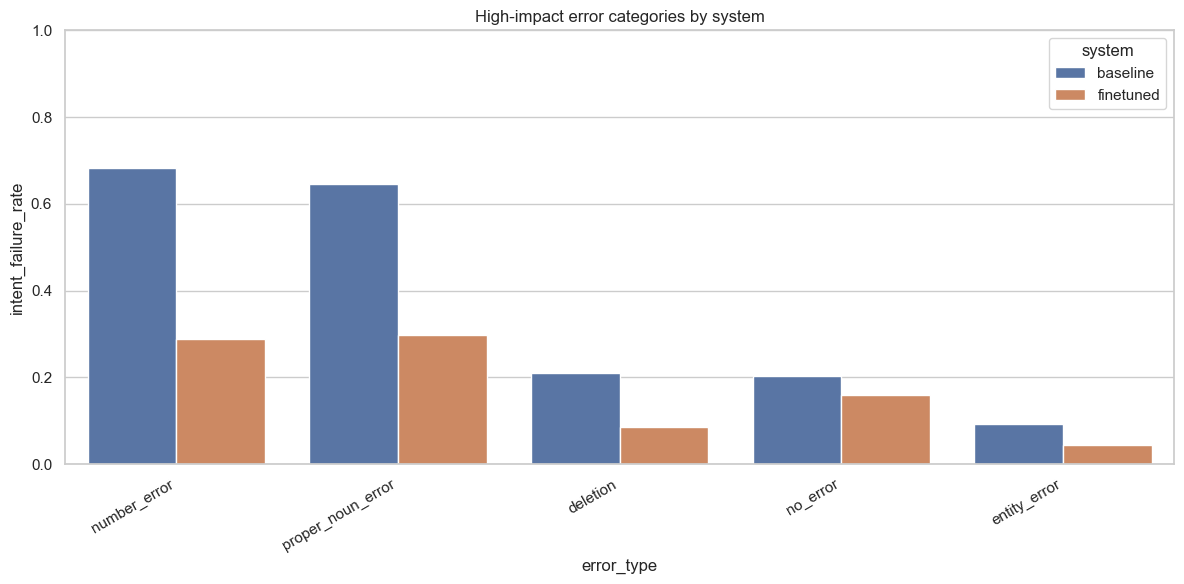

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=semantic_impact_df, x="error_type", y="intent_failure_rate", hue="system")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.0)
plt.title("High-impact error categories by system")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "high_impact_error_categories.png", dpi=150)
plt.show()


## Cell 18 — Plot category recovery


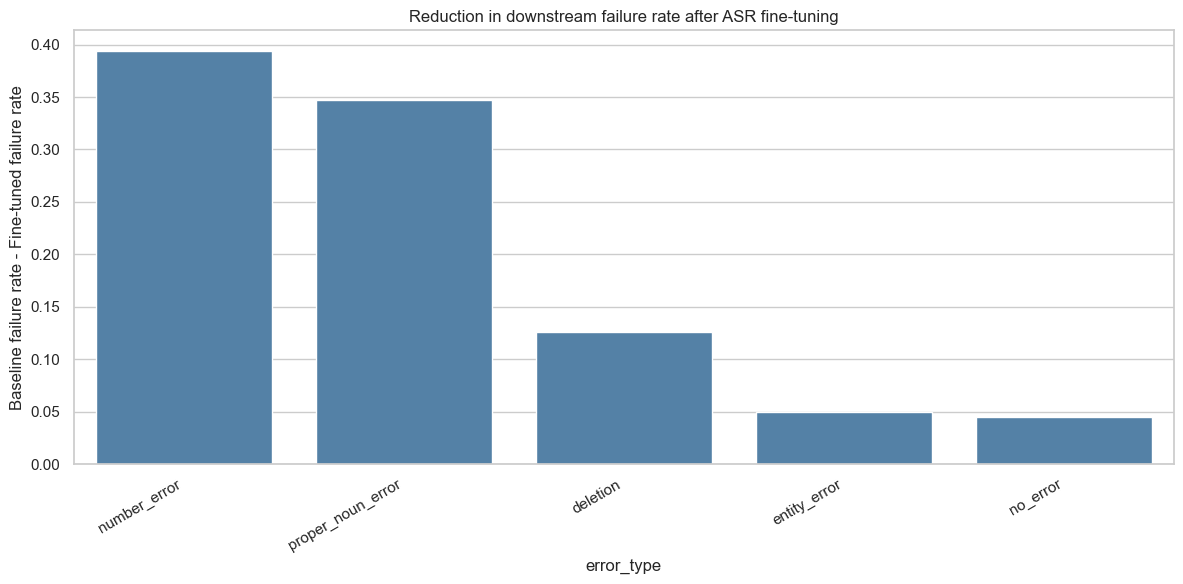

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=category_recovery_df, x="error_type", y="failure_rate_reduction", color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.title("Reduction in downstream failure rate after ASR fine-tuning")
plt.ylabel("Baseline failure rate - Fine-tuned failure rate")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "category_recovery_analysis.png", dpi=150)
plt.show()


## Cell 19 — Plot fragile supported intents


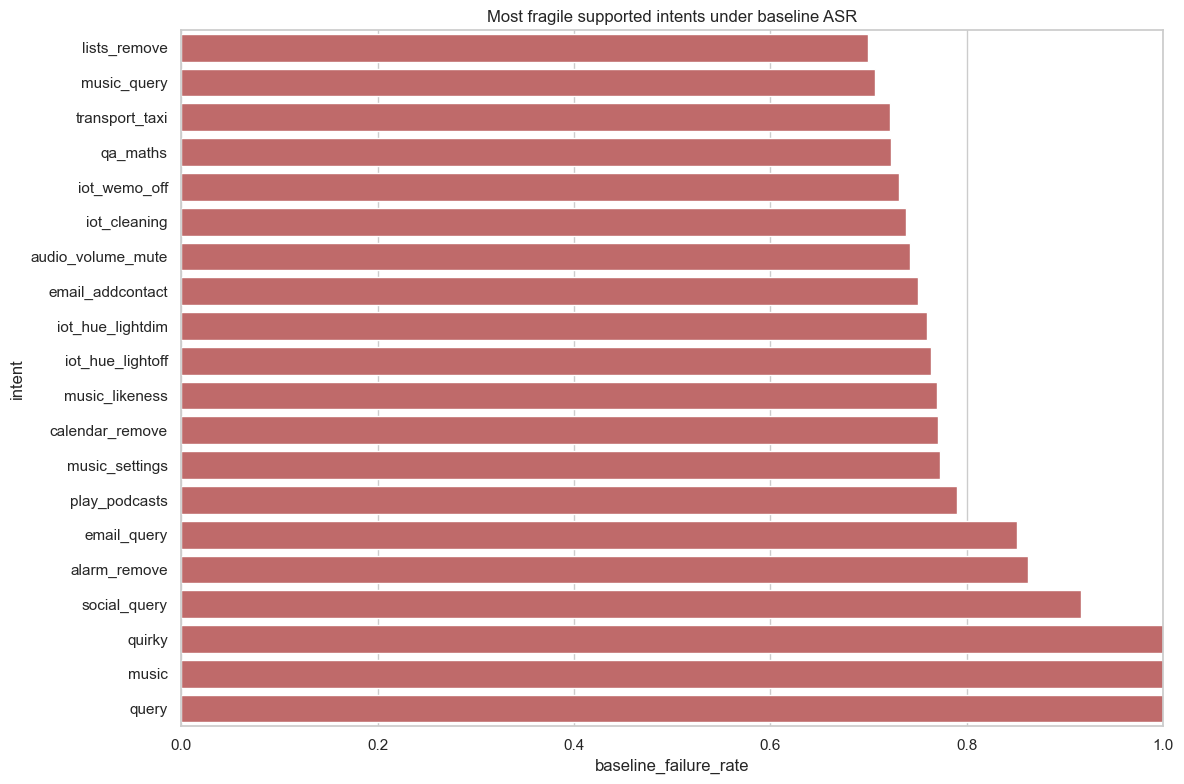

In [20]:
plot_fragile_supported_df = fragile_supported_intents_df.head(20).sort_values("baseline_failure_rate", ascending=True)
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_fragile_supported_df, y="intent", x="baseline_failure_rate", color="indianred")
plt.xlim(0, 1.0)
plt.title("Most fragile supported intents under baseline ASR")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "fragile_supported_intents.png", dpi=150)
plt.show()


## Cell 20 — Save Notebook 14 outputs


In [21]:
semantic_impact_df.to_csv(REPORTS_DIR / "semantic_impact_matrix.csv", index=False)
category_recovery_df.to_csv(REPORTS_DIR / "category_recovery_analysis.csv", index=False)
fragile_intents_df.to_csv(REPORTS_DIR / "fragile_intents_ranked.csv", index=False)
fragile_supported_intents_df.to_csv(REPORTS_DIR / "fragile_supported_intents.csv", index=False)
category_conditioned_fragility_df.to_csv(REPORTS_DIR / "category_conditioned_fragility.csv", index=False)
recovery_by_error_df.to_csv(REPORTS_DIR / "recovery_by_error_type.csv", index=False)
persistent_high_impact_summary_df.to_csv(REPORTS_DIR / "persistent_high_impact_errors.csv", index=False)
recovered_high_impact_summary_df.to_csv(REPORTS_DIR / "recovered_high_impact_errors.csv", index=False)
semantic_case_studies_df.to_csv(REPORTS_DIR / "semantic_case_studies.csv", index=False)
explanatory_signal_df.to_csv(REPORTS_DIR / "taxonomy_vs_editcount_signal.csv", index=False)

summary = {
    "n_rows": int(len(taxonomy_df)),
    "ground_truth_accuracy": float(metric_comparison_df.loc[metric_comparison_df["transcript_source"] == "ground_truth", "accuracy"].iloc[0]),
    "baseline_accuracy": float(metric_comparison_df.loc[metric_comparison_df["transcript_source"] == "baseline", "accuracy"].iloc[0]),
    "finetuned_accuracy": float(metric_comparison_df.loc[metric_comparison_df["transcript_source"] == "finetuned", "accuracy"].iloc[0]),
    "baseline_edit_auc": None if pd.isna(baseline_auc_edits) else float(baseline_auc_edits),
    "finetuned_edit_auc": None if pd.isna(finetuned_auc_edits) else float(finetuned_auc_edits),
}
with open(REPORTS_DIR / "high_impact_error_analysis_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved Notebook 14 outputs.")


Saved Notebook 14 outputs.


## Cell 21 — Final interpretation


In [ ]:
print("=" * 72)
print("HIGH-IMPACT ERROR ANALYSIS SUMMARY")
print("=" * 72)
print("Top harmful baseline categories:")
print(most_harmful_baseline_df[["error_type", "samples", "intent_failure_rate"]].to_string(index=False))
print()
print("Top recovered categories:")
print(category_recovery_df[["error_type", "failure_rate_reduction", "baseline_samples", "finetuned_samples"]].to_string(index=False))
print()
print("Saved outputs to reports/ including:")
print("- semantic_impact_matrix.csv")
print("- category_recovery_analysis.csv")
print("- fragile_supported_intents.csv")
print("- recovery_by_error_type.csv")
print("- semantic_case_studies.csv")
print("- high_impact_error_analysis_summary.json")

HIGH-IMPACT ERROR ANALYSIS SUMMARY
Top harmful baseline categories:
       error_type  samples  intent_failure_rate
     number_error      488             0.682377
proper_noun_error     7573             0.645451
         deletion       19             0.210526
         no_error      565             0.203540
     entity_error       43             0.093023

Top recovered categories:
       error_type  failure_rate_reduction  baseline_samples  finetuned_samples
     number_error                0.393839               488                253
proper_noun_error                0.347162              7573               6487
         deletion                0.125781                19                 59
     entity_error                0.049545                43                 46
         no_error                0.044560               565               1843

Saved outputs to reports/ including:
- semantic_impact_matrix.csv
- category_recovery_analysis.csv
- fragile_supported_intents.csv
- recovery_

## Conclusion

This notebook strengthens the main research claim of VoxIntel: **not all ASR errors are equally harmful to downstream intent understanding**.

### Main findings

- **Number-related** and **proper-noun-like** transcription errors are the most damaging categories in the baseline pipeline, with the highest downstream intent failure rates.
- Fine-tuning the ASR model does not only improve transcription quality overall — it also **reduces the downstream impact of the most harmful error categories**.
- Some categories, such as **deletions** and **entity-like errors**, appear comparatively less harmful on average, suggesting that the intent model can tolerate certain transcript imperfections when core meaning is preserved.
- The project also identifies a set of **fragile intents** that remain highly vulnerable even after ASR improvement, indicating that downstream weakness is not caused by ASR alone.
- Simple numeric proxies such as **edit count** have useful signal, but they do not fully explain downstream failures by themselves. This supports the need for **category-aware error analysis** rather than relying only on aggregate WER/CER-style measures.

### Research interpretation

Together, these results move VoxIntel beyond the statement:

> “Fine-tuning improves WER.”

toward the more meaningful conclusion:

> **Fine-tuning improves end-to-end speech understanding partly because it reduces the frequency and impact of high-risk transcription error categories.**

This is the key analytical contribution of the project so far.

### Important limitation

The taxonomy is now functional and informative, but it is still **heuristic** rather than fully human-annotated. In particular, the `proper_noun_error` family remains broad and should be interpreted carefully until further refinement or manual validation is completed.

### Next step

The natural next research step is to test whether **taxonomy-aware features explain intent failures better than coarse ASR metrics alone**. In other words:

> **Is WER enough, or does error taxonomy provide additional explanatory power for downstream failure prediction?**